### Clase 14 - OLS Practica




### 0. Configuramos el entorno de trabajo

In [18]:
# Importamos las librerias necesarias
from statsmodels.stats.descriptivestats import describe
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [19]:
# Cargar conjunto de datos de ejemplo
df = pd.read_csv("mtcars.csv")

### 1. EDA: Exploratory Data Analysis (Análisis Exploratorio de Datos)

#### 1. Hacemos una exploración simple

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


In [21]:
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


#### 3. Detectamos y eliminamos registros duplicados

In [22]:
# Detectar registros duplicados en el dfFrame df
duplicados = df[df.duplicated()]
print("Registros duplicados:")
print(duplicados)

Registros duplicados:
Empty DataFrame
Columns: [model, mpg, cyl, disp, hp, drat, wt, qsec, vs, am, gear, carb]
Index: []


#### 2. Detectamos y tratamos los datos faltantes

In [23]:
# Detectar valores nulos en el DataFrame df
null_counts = df.isnull().sum()
print("Valores nulos por columna:")
print(null_counts)

Valores nulos por columna:
model    0
mpg      0
cyl      0
disp     0
hp       0
drat     0
wt       0
qsec     0
vs       0
am       0
gear     0
carb     0
dtype: int64


#### 5. Hacemos un summary de los datos

In [24]:
# Usar describe de statsmodels para obtener estadísticas descriptivas
describe(df)


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
nobs,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
missing,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.812500
std_err,1.065424,0.315709,21.909473,12.120317,0.094519,0.172968,0.315890,0.089098,0.088210,0.130427,0.285530
upper_ci,22.178818,6.806279,273.663652,170.442885,3.781816,3.556262,18.467883,0.612129,0.579138,3.943131,3.372128
lower_ci,18.002432,5.568721,187.780098,122.932115,3.411309,2.878238,17.229617,0.262871,0.233362,3.431869,2.252872
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.615200
iqr,7.375000,4.000000,205.175000,83.500000,0.840000,1.028750,2.007500,1.000000,1.000000,1.000000,2.000000
iqr_normal,5.467096,2.965204,152.096455,61.898643,0.622693,0.762614,1.488162,0.741301,0.741301,0.741301,1.482602
mad,4.714453,1.585938,108.785742,56.480469,0.453242,0.730187,1.376172,0.492188,0.482422,0.644531,1.300781


#### 6. Hacemos una exploración visual rápida.

##### 6.1 Scatter Plot

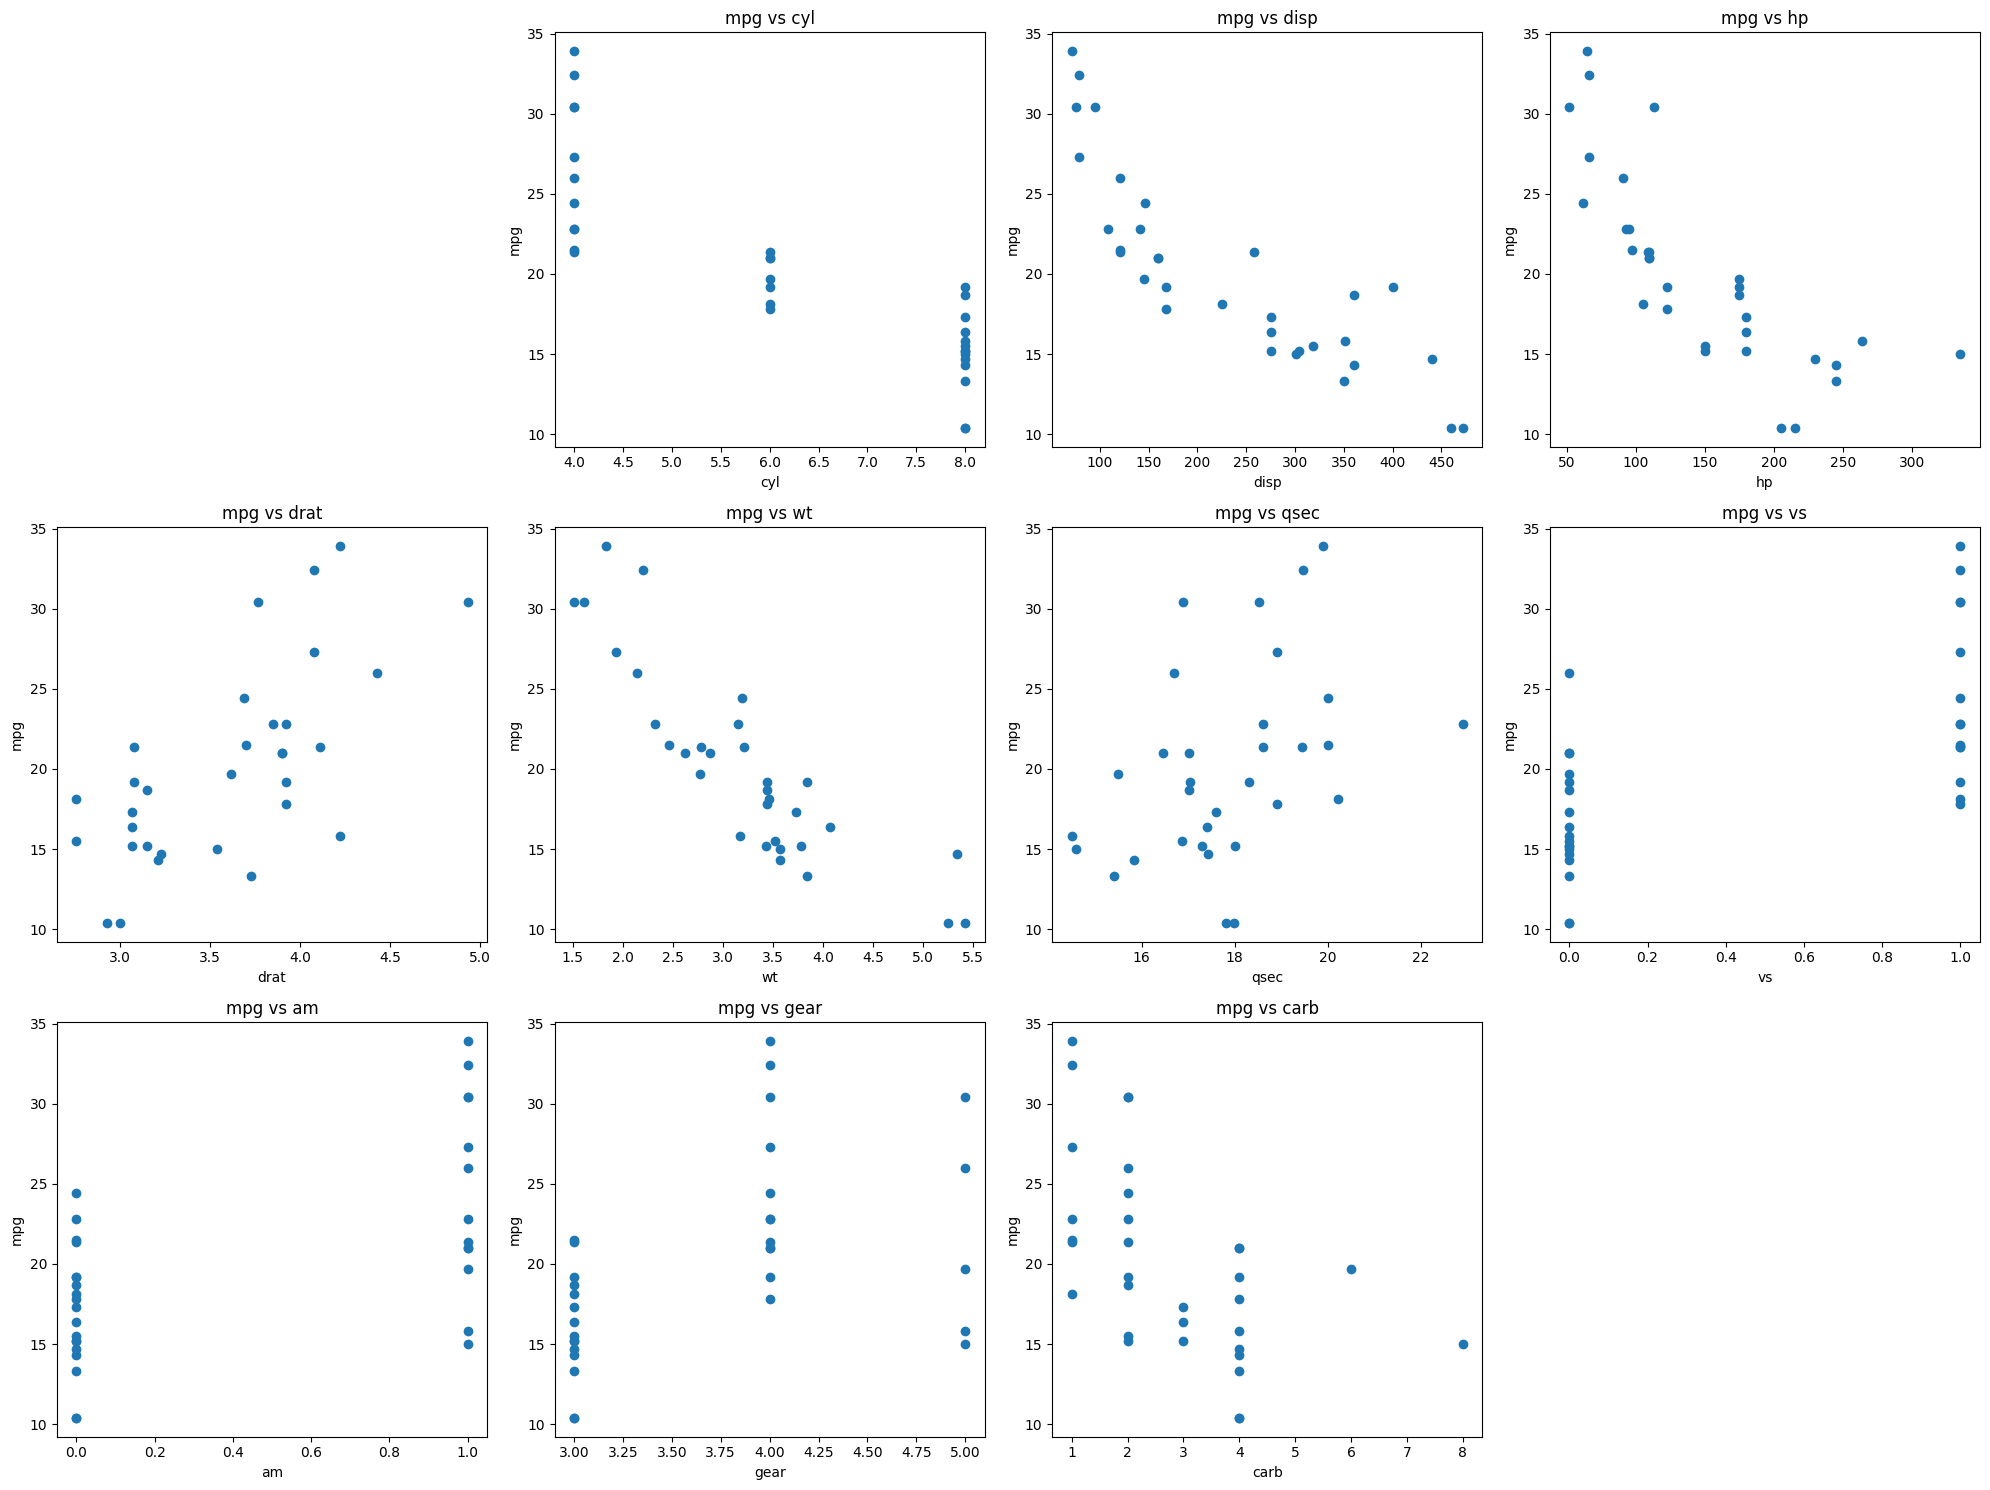

In [25]:
# Crear un scatter plot de cada columna numérica contra 'mpg'
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if col != 'mpg':
        axes[i].scatter(df[col], df['mpg'])
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('mpg')
        axes[i].set_title(f'mpg vs {col}')
    else:
        axes[i].axis('off')

# Ocultar ejes vacíos si hay menos de 12 columnas
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

##### 6.2 Hacemos histogramas

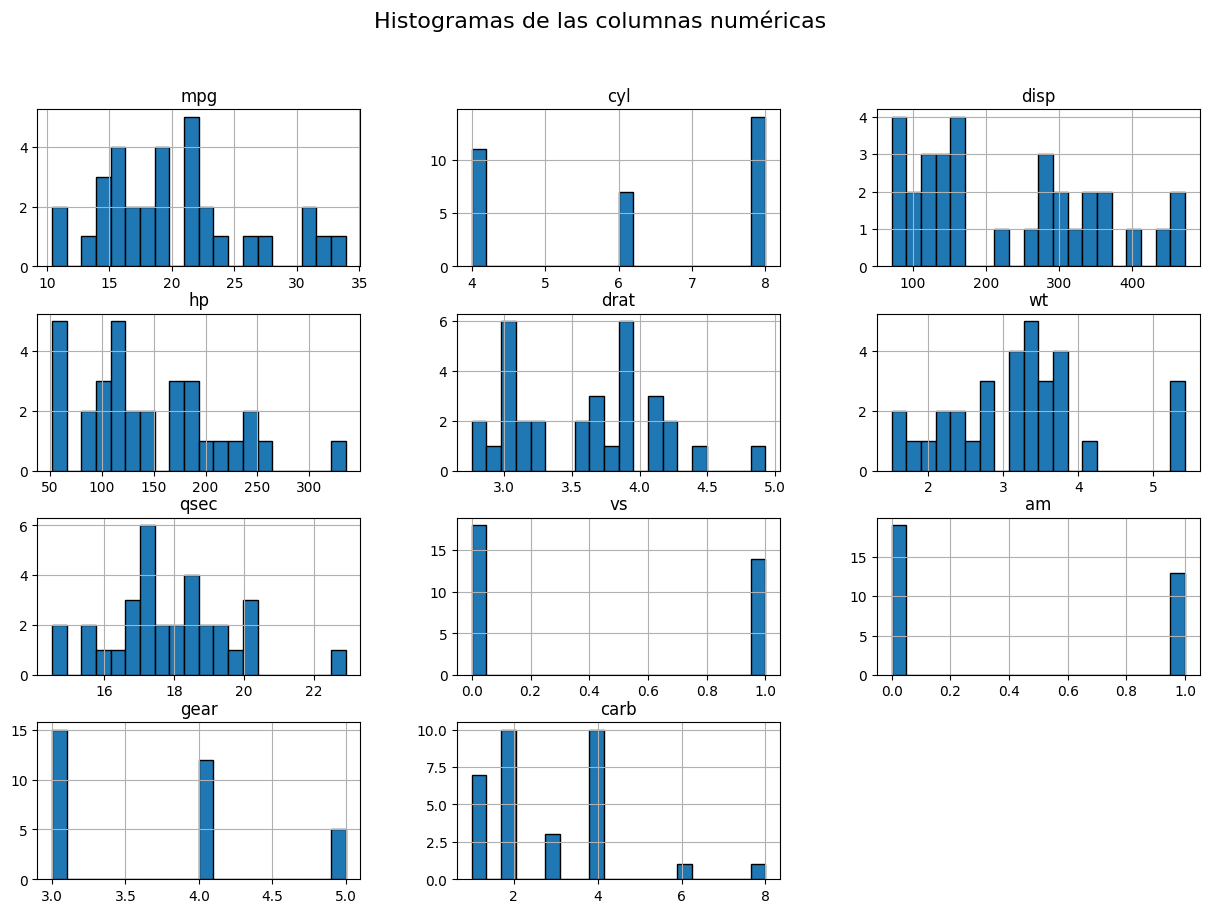

In [26]:
# Generar histogramas para las columnas numéricas
df.hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle("Histogramas de las columnas numéricas", fontsize=16)
plt.show()

##### 6.3 Hacemos Par plots

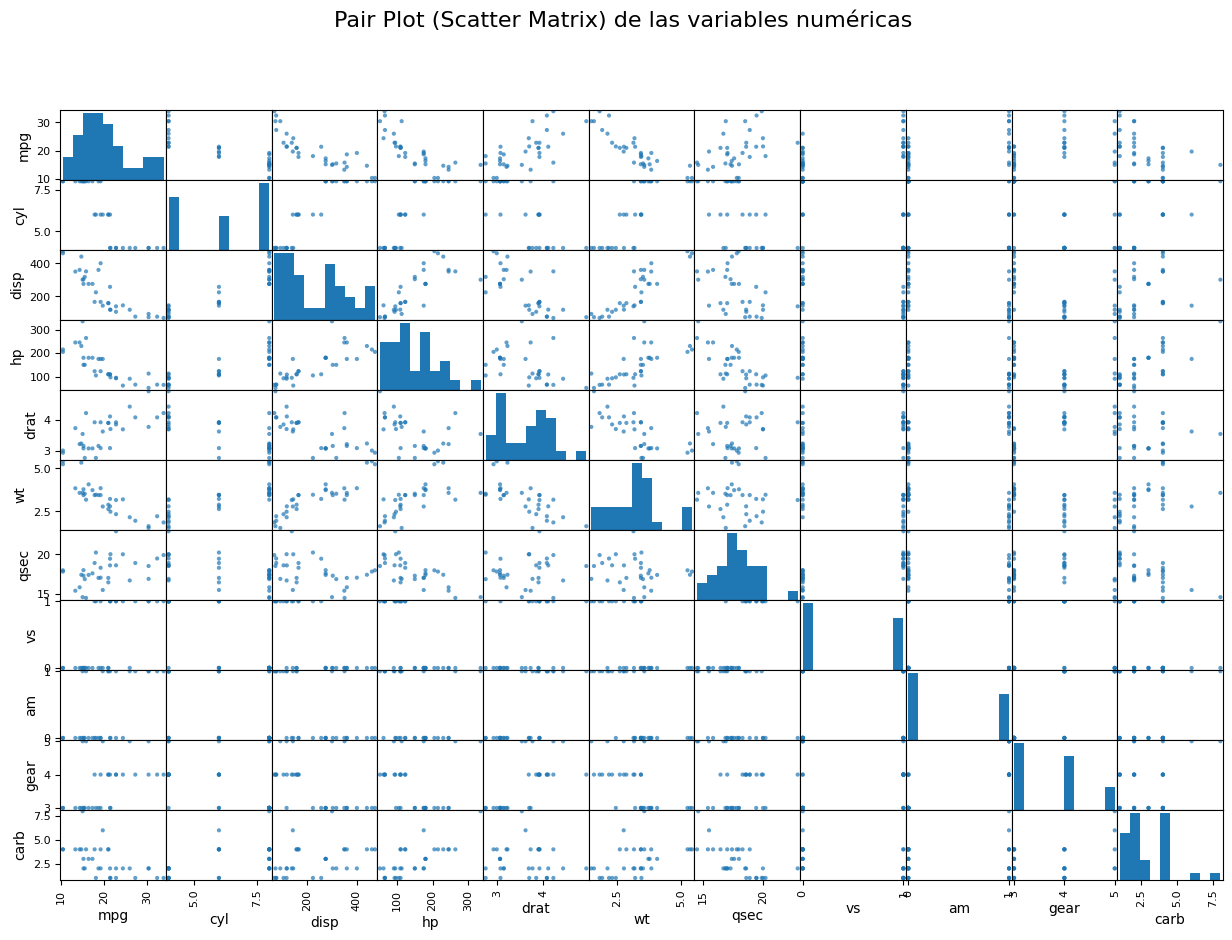

In [27]:
from pandas.plotting import scatter_matrix

scatter_matrix(df, figsize=(15, 10), diagonal='hist', alpha=0.7)
plt.suptitle("Pair Plot (Scatter Matrix) de las variables numéricas", fontsize=16)
plt.show()

### 2. Detección y Tratamiento de Outliers y Datos Faltantes

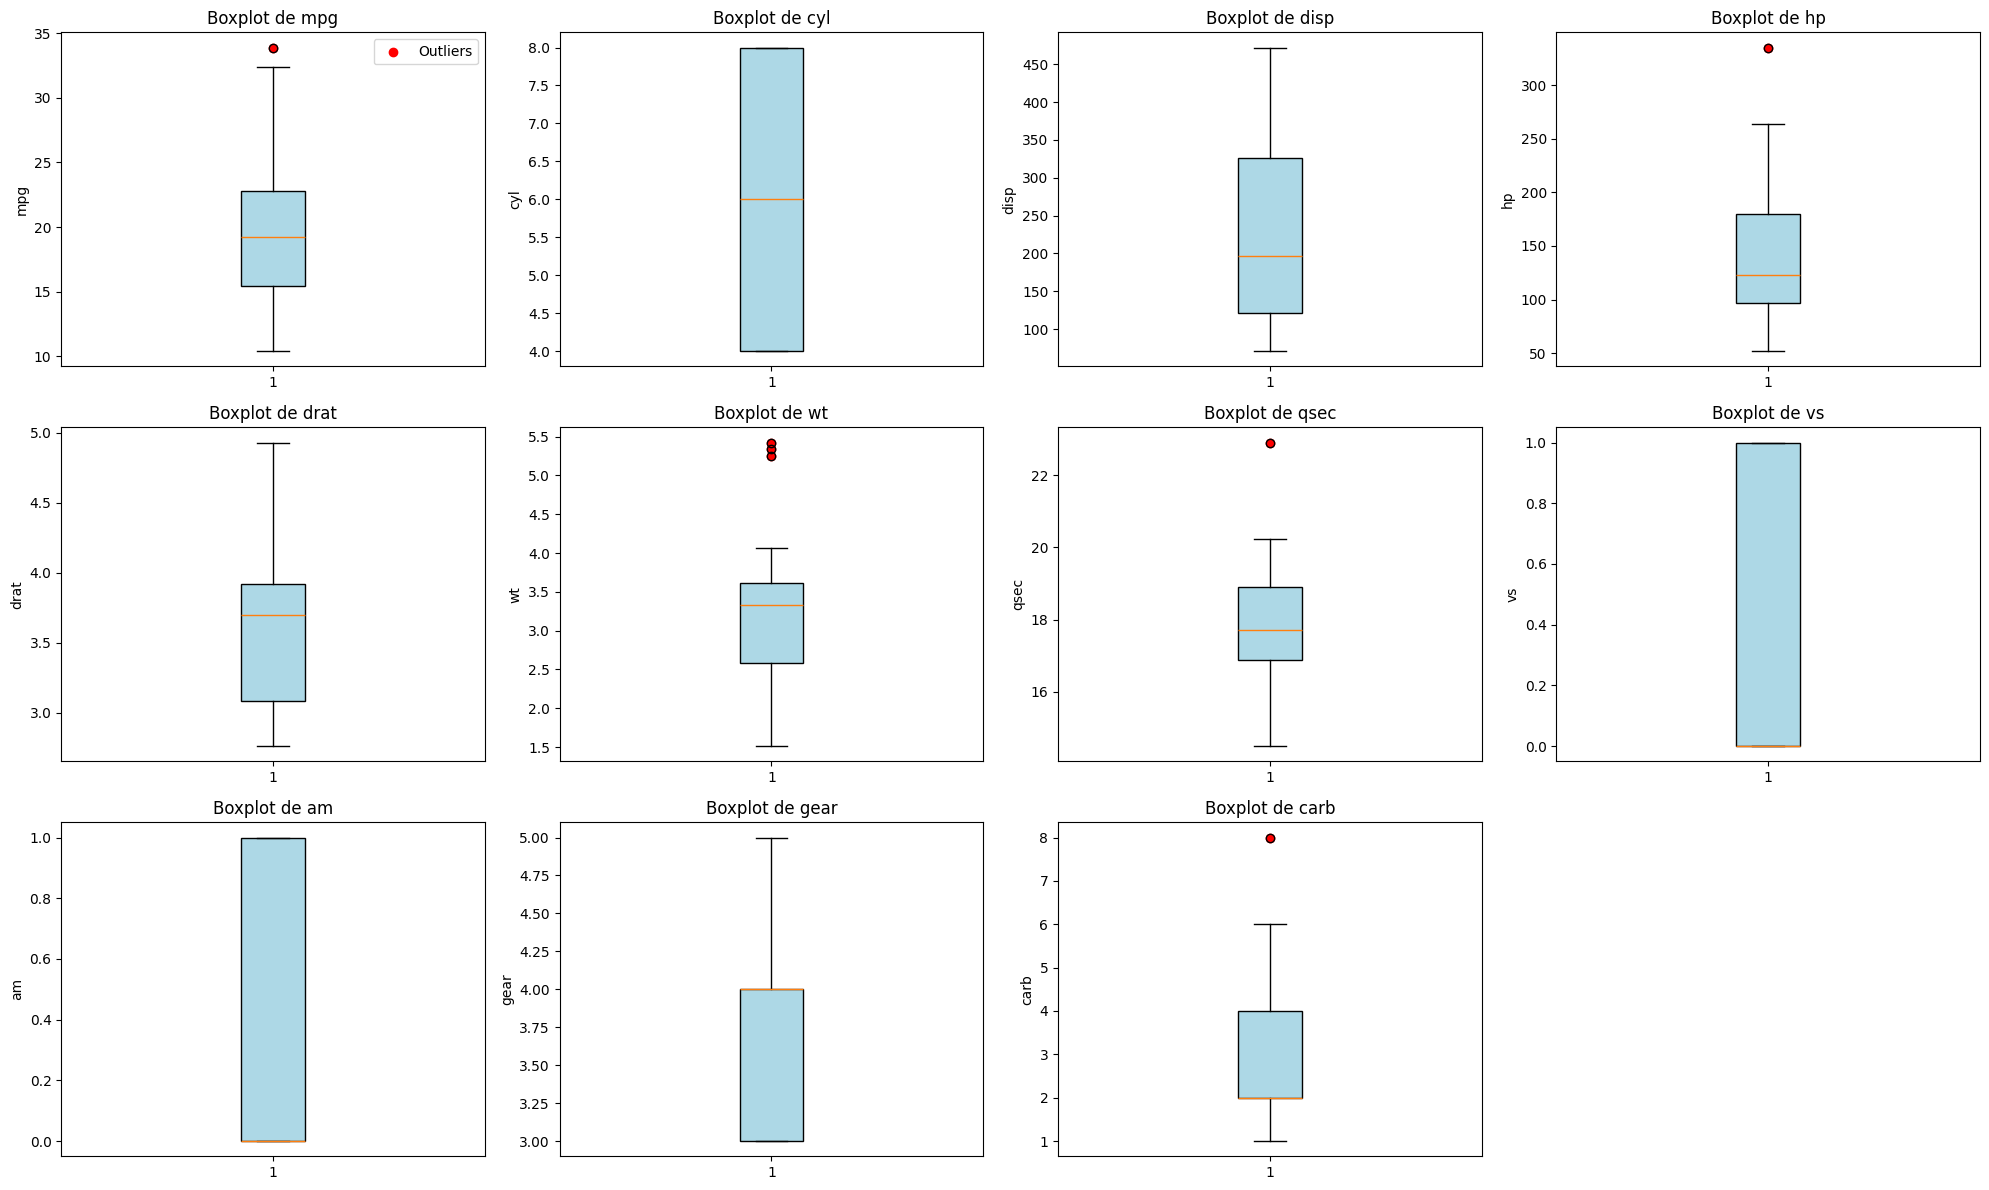

In [28]:
# Crear boxplots para cada columna numérica y marcar outliers
fig, axes_box = plt.subplots(nrows=3, ncols=4, figsize=(20, 12))
axes_box = axes_box.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes_box[idx]
    ax.boxplot(df[col], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    ax.set_title(f'Boxplot de {col}')
    ax.set_ylabel(col)
    # Detección de outliers usando el método IQR
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    if not outliers.empty:
        ax.scatter([1]*len(outliers), outliers, color='red', label='Outliers')
    if idx == 0 and not outliers.empty:
        ax.legend()

# Ocultar ejes vacíos si hay menos de 12 columnas
for idx in range(len(numeric_cols), len(axes_box)):
    axes_box[idx].axis('off')

plt.tight_layout()
plt.show()

### 3. Regresión Lineal Simple

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     45.46
Date:                Thu, 30 Oct 2025   Prob (F-statistic):           1.79e-07
Time:                        19:35:09   Log-Likelihood:                -87.619
No. Observations:                  32   AIC:                             179.2
Df Residuals:                      30   BIC:                             182.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.0989      1.634     18.421      0.0

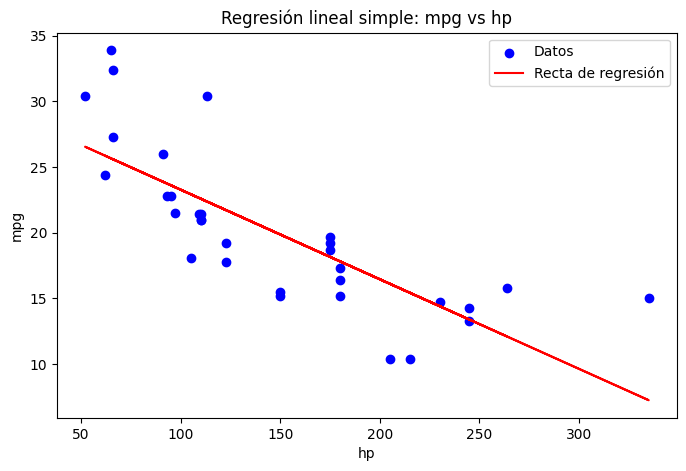

In [29]:
# Ejemplo de regresión lineal simple: mpg vs hp
import statsmodels.api as sm

X = df['hp']
y = df['mpg']

# Agregar constante para el intercepto
X_const = sm.add_constant(X)

# Ajustar el modelo
modelo = sm.OLS(y, X_const).fit()

# Mostrar resumen del modelo
print(modelo.summary())

# Graficar los datos y la recta de regresión
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Datos')
plt.plot(X, modelo.predict(X_const), color='red', label='Recta de regresión')
plt.xlabel('hp')
plt.ylabel('mpg')
plt.title('Regresión lineal simple: mpg vs hp')
plt.legend()
plt.show()

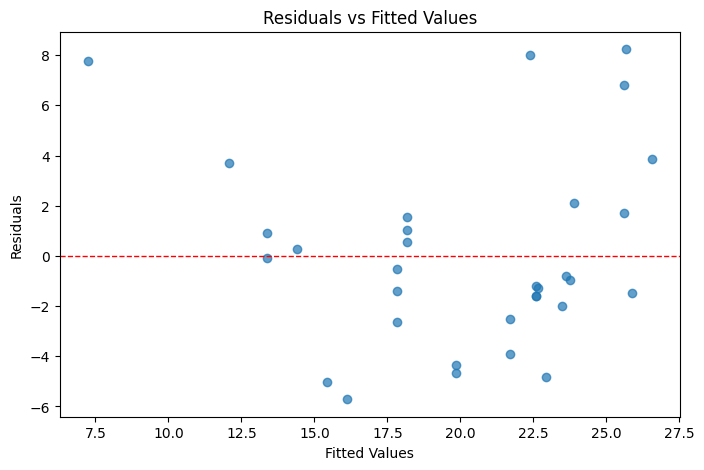

In [30]:
# Get residuals
residuals = modelo.resid

# Plot residuals
plt.figure(figsize=(8, 5))
plt.scatter(modelo.fittedvalues, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

In [31]:
# Crear una tabla con valores reales y predichos de mpg
tabla_resultados = df[['mpg']].copy()
tabla_resultados['mpg_predicho'] = modelo.predict(X_const)
tabla_resultados


,mpg,mpg_predicho
0,21.0,22.593750
1,21.0,22.593750
2,22.8,23.753631
3,21.4,22.593750
4,18.7,18.158912
5,18.1,22.934891
6,14.3,13.382932
7,24.4,25.868707
8,22.8,23.617174
9,19.2,21.706782
